# FlexBend N4SID identification

SISO educated guess: order 3, $SS_f=SS_p=20$, stable $A$, $D=0$. Same train/dev/test split as the Koopman notebooks.


In [6]:
import os
# OpenMP/MKL + PyTorch on macOS segfaults the Jupyter kernel during backward
# unless thread counts are pinned before numpy/torch are imported.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

torch.set_num_threads(1)

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.insert(0, os.path.join(os.getcwd()))
sys.path.insert(0, os.path.join(project_root, "src"))
IDENT_DIR = Path.cwd()
DATA_DIR = IDENT_DIR.parent / "data"

import helper
from data_utils import NSTEPS, TS, load_flexy_splits, save_flexy_npz
from helper.koopman import (
    LossWeights,
    TrainConfig,
    build_koopman_problem,
    evaluate_mae_physical,
    extract_matrices,
    get_data_loaders,
    train_koopman,
)

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading a Dataset


Ts = 0.05 s, nsteps = 40, train 3800 / dev 760 / test 2280
train ids [1, 2, 3, 4, 5] ['40 -> 80', '50 -> 80', '20 -> 40', '30 -> 10', '70 -> 30']
dev ids   [6] ['40 -> 90']
test ids  [7, 8, 9] ['40 -> 80', '50 -> 80', '35 -> 55']


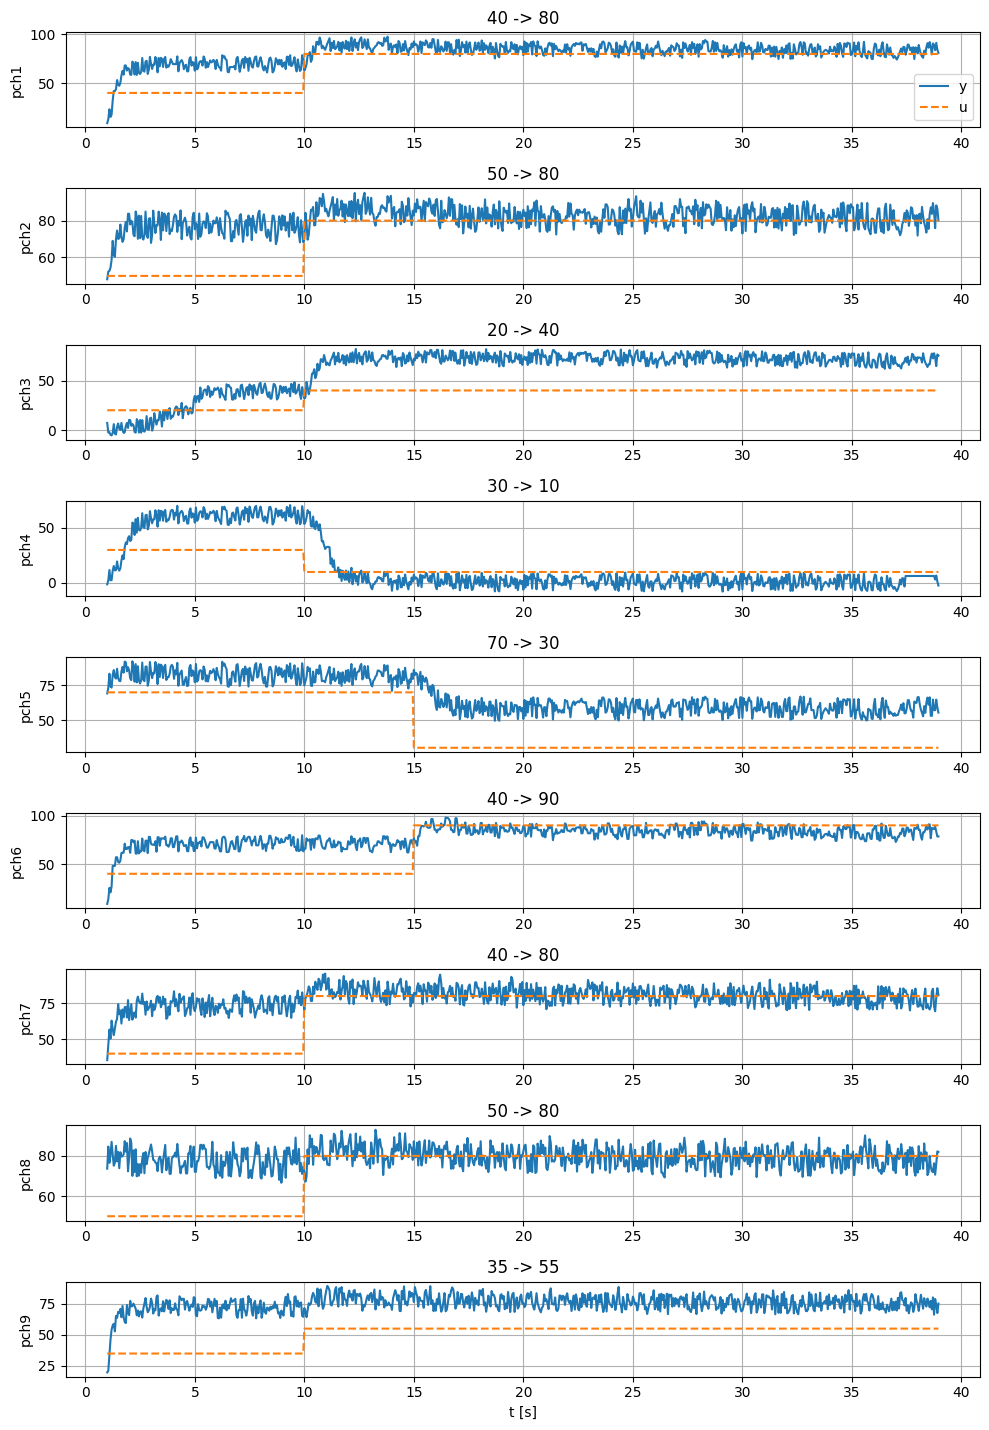

In [7]:
experiments, train_exps, dev_exps, test_exps, train, dev, test = load_flexy_splits()
save_flexy_npz()
y_names = ["y"]
print(
    f"Ts = {TS} s, nsteps = {NSTEPS}, "
    f"train {train['Y'].shape[0]} / dev {dev['Y'].shape[0]} / test {test['Y'].shape[0]}"
)
print("train ids", [e["id"] for e in train_exps], [e["label"] for e in train_exps])
print("dev ids  ", [e["id"] for e in dev_exps], [e["label"] for e in dev_exps])
print("test ids ", [e["id"] for e in test_exps], [e["label"] for e in test_exps])

n_plot = len(experiments)
fig, axs = plt.subplots(n_plot, 1, figsize=(10, 1.6 * n_plot), sharex=False)
for ax, exp in zip(axs, experiments.values()):
    ax.plot(exp["t"], exp["Y"][:, 0], label="y")
    ax.plot(exp["t"], exp["U"][:, 0], "--", label="u")
    ax.set_ylabel(f"pch{exp['id']}")
    ax.set_title(exp["label"])
    ax.grid(True)
axs[0].legend(loc="best")
axs[-1].set_xlabel("t [s]")
fig.tight_layout()


## Scaled identification data


In [8]:
scaler = StandardScaler().fit(train["Y"])
scalerU = StandardScaler().fit(train["U"])
joblib.dump(scaler, DATA_DIR / "scaler_flexy.pkl")
joblib.dump(scalerU, DATA_DIR / "scalerU_flexy.pkl")
train_s = {"Y": scaler.transform(train["Y"]), "U": scalerU.transform(train["U"])}
dev_s = {"Y": scaler.transform(dev["Y"]), "U": scalerU.transform(dev["U"])}
test_s = {"Y": scaler.transform(test["Y"]), "U": scalerU.transform(test["U"])}
y_tot = train_s["Y"].T.copy()
U = train_s["U"].T.copy()
print(y_tot.shape, U.shape)


(1, 3800) (1, 3800)


## N4SID


In [9]:
import sippy_unipi.functionsetSIM as fsetSIM
import sippy_unipi.OLSims_methods as olm
from sippy_unipi.model import SS_Model

def _vn_mat_dot(y, yest):
    eps = np.asarray(y).reshape(-1) - np.asarray(yest).reshape(-1)
    return float(np.dot(eps, eps) / max(eps.size, 1))

fsetSIM.Vn_mat = _vn_mat_dot
olm.Vn_mat = _vn_mat_dot

N4SID_ORDER = 3
N4SID_SS_F = 20
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    ident = SS_Model._identify(
        y_tot,
        U,
        "N4SID",
        N4SID_ORDER,
        f=N4SID_SS_F,
        p=N4SID_SS_F,
        threshold=0.0,
        D_required=False,
        A_stability=True,
        B_recalc=False,
    )

A, B, C, D = ident.A, ident.B, ident.C, ident.D
print("A\n", A)
print("rho(A)", float(np.max(np.abs(np.linalg.eigvals(A)))))
np.save(DATA_DIR / "A_flexy_n4sid.npy", A)
np.save(DATA_DIR / "B_flexy_n4sid.npy", B)
np.save(DATA_DIR / "C_flexy_n4sid.npy", C)
np.save(DATA_DIR / "D_flexy_n4sid.npy", D)


A
 [[ 0.99397104 -0.02557619 -0.00210469]
 [-0.00361429  0.82419726 -0.02903103]
 [-0.00210911 -0.58315128 -0.8682156 ]]
rho(A) 0.9945268768484383


## Test simulation


concatenated test MAE (physical): [11.85538175]


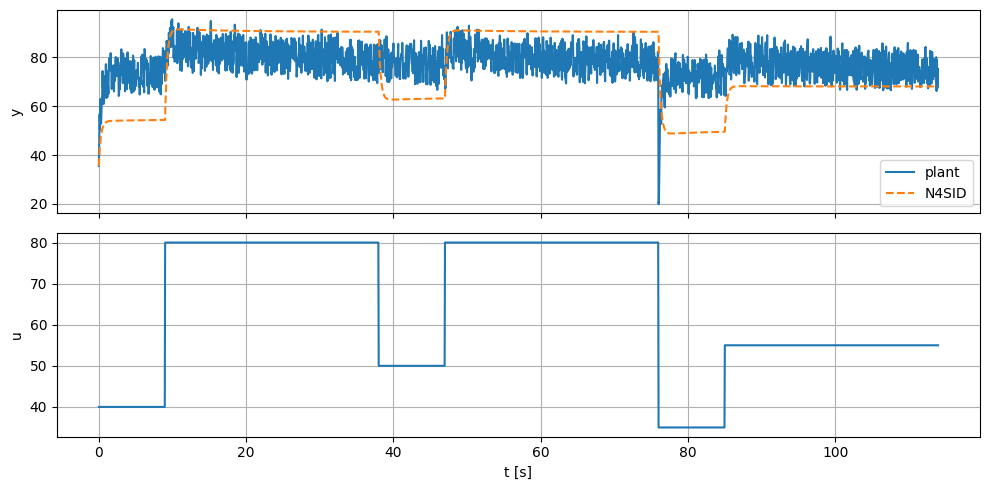

In [10]:
def ss_lsim(A, B, C, D, U, x0):
    N = U.shape[1]
    y = np.zeros((C.shape[0], N))
    x = np.asarray(x0, dtype=float).reshape(-1)
    for k in range(N):
        uk = U[:, k]
        y[:, k] = C @ x + D @ uk
        x = A @ x + B @ uk
    return y

U_test = test_s["U"].T
Y_test = test_s["Y"].T
x0 = np.linalg.pinv(C) @ Y_test[:, :1]
yhat_s = ss_lsim(A, B, C, D, U_test, x0)
yhat = scaler.inverse_transform(yhat_s.T)
ytrue = scaler.inverse_transform(Y_test.T)
mae = np.mean(np.abs(ytrue - yhat), axis=0)
print("concatenated test MAE (physical):", mae)

t = np.arange(ytrue.shape[0]) * TS
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, ytrue[:, 0], label="plant")
ax[0].plot(t, yhat[:, 0], "--", label="N4SID")
ax[0].set_ylabel("y")
ax[0].legend()
ax[0].grid(True)
ax[1].plot(t, test["U"][:, 0])
ax[1].set_ylabel("u")
ax[1].set_xlabel("t [s]")
ax[1].grid(True)
fig.tight_layout()
